# Regulated Steady State: Amortizing the Solve, Not Learning the Kinetics

Notebook 10 learned an uncertain rate law inside a trusted stoichiometric scaffold —
a *calibration* problem. That is real, but it is **not** the reason kinetic metabolic
models don't scale. The scaling gap is different:

- **Knowledge gap** — we don't know the rate laws. (Notebook 10. Calibration.)
- **Scaling gap** — even with the kinetics known, integrating large, stiff, allosterically
  coupled ODEs is expensive, and the real workload is rarely one transient. It is the
  **steady-state flux distribution under regulation, over many conditions** (genotypes,
  media, knockouts) — i.e. *regulated FBA*. That means thousands–millions of solves.

This notebook targets the scaling gap directly, with two ideas that play to this
project's strengths and **do not** route through PINNs (which are notoriously poor on
stiff kinetics):

1. **Exact conservation as linear algebra.** A metabolic network's conserved moieties
   are the *left null space* of the stoichiometric matrix `S` — exact linear algebra,
   Cajal's wheelhouse. Using it to solve the steady state **in reduced coordinates**
   makes an otherwise-singular nonlinear solve well-posed, cuts the dimension, and pins
   mass balance to machine precision.
2. **Amortization.** Solve the regulated steady state for many conditions once, then
   train a cheap surrogate `conditions → steady state` that is evaluated in the reduced
   coordinates, so it is fast *and* cannot violate conservation.

We use a scalable synthetic network so we can push the size up and watch the cost.

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.func import jacrev
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from cajal.syntax import TyReal, TyFun
from cajal.compiling import compile, TypedTensor

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

# A length-L conversion chain with a committed, cofactor-coupled, feedback-inhibited
# first step, plus ONE conserved cofactor pool (a reduced / b oxidized, T = a + b).
#   in: -> m_0 ; step_0: m_0 + b -> m_1 + a (inhibited by end product m_{L-1}) ;
#   step_i: m_i -> m_{i+1} ; regen: a -> b ; out: m_{L-1} ->
def build_network(L):
    n_met, n_rxn, ia, ib = L + 2, L + 2, L, L + 1
    S = torch.zeros(n_met, n_rxn)
    r_regen, r_out = L, L + 1
    S[0, 0] = 1.0                                   # in
    S[0, 1] = -1.0; S[ib, 1] = -1.0; S[1, 1] = 1.0; S[ia, 1] = 1.0   # step_0 (cofactor)
    for i in range(1, L - 1):                        # simple conversions
        S[i, 1 + i] = -1.0; S[i + 1, 1 + i] = 1.0
    S[ia, r_regen] = -1.0; S[ib, r_regen] = 1.0     # regen a -> b
    S[L - 1, r_out] = -1.0                           # out
    c = torch.zeros(n_met); c[ia] = c[ib] = 1.0      # conserved moiety a + b
    return dict(L=L, n_met=n_met, n_rxn=n_rxn, S=S, ia=ia, ib=ib, c=c)

P = dict(kcat=2.0, kstep=2.5, Km=0.4, Kmb=0.3, k_regen=2.0, k_out=2.0, Ki=0.6, h=2.0)

def fluxes(x, net, cond, p=P):
    L = net['L']; mm = lambda s, Km: s / (Km + s)
    m, a, b = x[:L], x[net['ia']], x[net['ib']]
    reg0 = 1.0 / (1.0 + (m[L - 1] / p['Ki'])**p['h'])     # end-product feedback inhibition
    vs = [cond['inflow'], p['kcat'] * mm(m[0], p['Km']) * mm(b, p['Kmb']) * reg0]
    for i in range(1, L - 1):
        vs.append(p['kstep'] * mm(m[i], p['Km']))
    vs.append(p['k_regen'] * mm(a, p['Km']) * cond['oxidant'])
    vs.append(p['k_out'] * mm(m[L - 1], p['Km']))
    return torch.stack(vs)

print('network + kinetics defined')

network + kinetics defined


## The trusted scaffold and its conserved moiety

`S` is the stoichiometric matrix; we expose it as a Cajal typed linear map
`TyReal(n_rxn) → TyReal(n_met)`, exactly as in notebook 10. The new ingredient is its
**left null space**: a covector `c` with `cᵀS = 0` is a *conserved moiety* — a linear
combination of metabolites the reactions can never change. Here the cofactor pool
`a + b` is conserved (`c` picks out `a` and `b`).

That single fact is what we exploit. At steady state we need `S·v(x) = 0`. Because
`cᵀS = 0`, the rows of `S` are linearly dependent, so the full-space steady-state
problem is **singular** — there is a whole family of steady states, one per value of the
conserved pool. Fixing the pool (`a + b = T`) and solving in **reduced coordinates**
`y = [m₀…m_{L-1}, a]`, with `b = T − a`, removes the singularity exactly.

In [2]:
net = build_network(8)
S_MAP = TypedTensor(net['S'], TyFun(TyReal(net['n_rxn']), TyReal(net['n_met'])))
cond = dict(inflow=torch.tensor(0.3), oxidant=torch.tensor(1.0)); T = 1.5

print('cᵀS  =', [round(v, 3) for v in (net['c'] @ net['S']).tolist()], ' -> conserved moiety a+b')

# steady-state residual in reduced coordinates (b = T - a)
def reduced_residual(y, net, cond, T):
    L = net['L']
    x = torch.cat([y[:L], y[L:L + 1], (T - y[L]).reshape(1)])
    dxdt = S_MAP @ TypedTensor(fluxes(x, net, cond), TyReal(net['n_rxn']))   # Cajal linear map
    keep = torch.tensor([i for i in range(net['n_met']) if i != net['ib']])
    return dxdt.data[keep]

def solve_steady(net, cond, T, iters=50, tol=1e-10, history=False):
    L = net['L']
    y = torch.cat([torch.full((L,), 0.5), torch.tensor([T / 2])])
    f = lambda yy: reduced_residual(yy, net, cond, T)
    hist, its = [], iters
    for k in range(iters):
        r = f(y); hist.append(r.norm().item())
        if r.norm() < tol:
            its = k; break
        dy = torch.linalg.solve(jacrev(f)(y), r)
        step = 1.0
        while step > 1e-8:
            yn = y - step * dy
            if (yn > 1e-9).all() and f(yn).norm() < r.norm():
                break
            step *= 0.5
        y = (y - step * dy).clamp_min(1e-9)
    x = torch.cat([y[:L], y[L:L + 1], (T - y[L]).reshape(1)])
    return (y, x, f(y).norm().item(), its, hist) if history else (y, x, f(y).norm().item(), its)

y, x, res, its, hist = solve_steady(net, cond, T, history=True)
print(f'reduced solve: ||S·v|| = {res:.1e} in {its} Newton iters')
print(f'conservation |a+b-T|  = {abs((x[net["ia"]]+x[net["ib"]]-T).item()):.1e}')
print(f'steady fluxes along chain (all = inflow at steady state): '
      f'{[round(v,3) for v in fluxes(x, net, cond).tolist()[:5]]} ...')

cᵀS  = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  -> conserved moiety a+b


reduced solve: ||S·v|| = 4.7e-15 in 6 Newton iters
conservation |a+b-T|  = 0.0e+00
steady fluxes along chain (all = inflow at steady state): [0.3, 0.3, 0.3, 0.3, 0.3] ...


## Why the reduction matters: the full-space solve is singular

If we ignore the conserved moiety and try to solve `S·v(x) = 0` over all metabolites,
Newton's linear system has a **zero singular value** — the conservation direction. The
reduced system does not.

In [3]:
full = lambda xx: net['S'] @ fluxes(xx, net, cond)
Jf = jacrev(full)(x);                       sv_full = torch.linalg.svdvals(Jf)
Jr = jacrev(lambda yy: reduced_residual(yy, net, cond, T))(y); sv_red = torch.linalg.svdvals(Jr)
print(f"full-space Jacobian {tuple(Jf.shape)}: min σ = {sv_full.min():.1e}  "
      f"rank = {torch.linalg.matrix_rank(Jf).item()}/{Jf.shape[0]}   -> SINGULAR")
print(f"reduced   Jacobian {tuple(Jr.shape)}: min σ = {sv_red.min():.1e}  "
      f"cond = {sv_red.max()/sv_red.min():.1e}   -> well-posed")

full-space Jacobian (10, 10): min σ = 1.0e-17  rank = 9/10   -> SINGULAR
reduced   Jacobian (9, 9): min σ = 8.0e-01  cond = 1.2e+01   -> well-posed


## Scaling: direct steady-state solve from L=4 to L=128

The interesting question you raised: does the structure-preserving solve actually buy us
anything as the network grows? We sweep the chain length and record Newton iterations,
wall-clock time, the steady-state residual, and the conservation error.

In [4]:
sizes, times, iters_list, res_list, cons_list = [], [], [], [], []
print(f"  {'L':>4} {'n_met':>6} {'iters':>6} {'time_ms':>8} {'||S·v||':>9} {'|a+b-T|':>9}")
for L in [4, 8, 16, 32, 64, 128]:
    nL = build_network(L)
    S_MAP = TypedTensor(nL['S'], TyFun(TyReal(nL['n_rxn']), TyReal(nL['n_met'])))
    t0 = time.perf_counter(); yy, xx, rr, it = solve_steady(nL, cond, T)
    dt = (time.perf_counter() - t0) * 1e3
    cv = abs((xx[nL['ia']] + xx[nL['ib']] - T).item())
    sizes.append(nL['n_met']); times.append(dt); iters_list.append(it)
    res_list.append(rr); cons_list.append(cv)
    print(f"  {L:>4} {nL['n_met']:>6} {it:>6} {dt:>8.1f} {rr:>9.1e} {cv:>9.1e}")
print('\nNewton iteration count is size-independent; conservation error stays at 0 by construction.')

     L  n_met  iters  time_ms   ||S·v||   |a+b-T|
     4      6      6     12.0   4.7e-15   0.0e+00
     8     10      6     13.7   4.7e-15   0.0e+00
    16     18      6     18.8   4.7e-15   0.0e+00
    32     34      6     28.0   4.7e-15   0.0e+00
    64     66      6     48.5   4.7e-15   0.0e+00


   128    130      6     90.9   4.7e-15   0.0e+00

Newton iteration count is size-independent; conservation error stays at 0 by construction.


## Amortization: train `conditions → steady state`, evaluate cheaply

Now the payoff for the many-solves workload. We fix the network (L=8) and treat the
**condition** — inflow, oxidant level, and cofactor pool size `T` — as the input. We
solve a few hundred conditions once (the expensive part), then fit a small surrogate
that maps a condition straight to the steady state. Crucially the surrogate predicts the
**reduced** state, so `b = T − a` is reconstructed exactly: the amortized model **cannot
break conservation**, unlike a black-box emulator.

In [5]:
Ls = 8; netS = build_network(Ls)
S_MAP = TypedTensor(netS['S'], TyFun(TyReal(netS['n_rxn']), TyReal(netS['n_met'])))

def sample_cond(n):
    return (torch.rand(n) * 0.5 + 0.15, torch.rand(n) * 1.5 + 0.5, torch.rand(n) * 1.5 + 0.7)

def solve_dataset(inflow, oxidant, Tval):
    Ys, Vs = [], []
    for inf, ox, Tv in zip(inflow, oxidant, Tval):
        cnd = dict(inflow=inf, oxidant=ox)
        yy, xx, rr, it = solve_steady(netS, cnd, Tv.item())
        Ys.append(yy); Vs.append(fluxes(xx, netS, cnd))
    return torch.stack(Ys), torch.stack(Vs)

inf_tr, ox_tr, T_tr = sample_cond(300)
t0 = time.perf_counter(); Ytr, Vtr = solve_dataset(inf_tr, ox_tr, T_tr)
gen_time = time.perf_counter() - t0
Ctr = torch.stack([inf_tr, ox_tr, T_tr], 1)
cmu, csd = Ctr.mean(0), Ctr.std(0)                       # standardize inputs

sur = nn.Sequential(nn.Linear(3, 96), nn.SiLU(), nn.Linear(96, 96), nn.SiLU(),
                    nn.Linear(96, Ls + 1), nn.Softplus())
opt = torch.optim.Adam(sur.parameters(), lr=2e-3)
for ep in range(3000):
    opt.zero_grad(); loss = ((sur((Ctr - cmu) / csd) - Ytr)**2).mean()
    loss.backward(); opt.step()
print(f'generated 300 training solves in {gen_time:.1f}s; surrogate train loss = {loss.item():.2e}')

# held-out evaluation: Newton vs surrogate
inf_te, ox_te, T_te = sample_cond(80)
Cte = torch.stack([inf_te, ox_te, T_te], 1)
t0 = time.perf_counter(); Yte, Vte = solve_dataset(inf_te, ox_te, T_te); newton_t = time.perf_counter() - t0
t0 = time.perf_counter()
with torch.no_grad():
    Yp = sur((Cte - cmu) / csd)
Vp, cverr = [], 0.0
for j in range(len(T_te)):
    xx = torch.cat([Yp[j, :Ls], Yp[j, Ls:Ls + 1], (T_te[j] - Yp[j, Ls]).reshape(1)])
    cverr = max(cverr, abs((xx[netS['ia']] + xx[netS['ib']] - T_te[j]).item()))
    Vp.append(fluxes(xx, netS, dict(inflow=inf_te[j], oxidant=ox_te[j])))
Vp = torch.stack(Vp); sur_t = time.perf_counter() - t0
flux_err = ((Vp - Vte).norm() / Vte.norm()).item()
print(f'evaluate 80 held-out conditions:')
print(f'  Newton solve : {newton_t*1e3:7.0f} ms')
print(f'  surrogate    : {sur_t*1e3:7.1f} ms   ({newton_t/sur_t:.0f}x faster)')
print(f'  flux relative error            : {flux_err:.2e}')
print(f'  conservation error (guaranteed): {cverr:.1e}')

generated 300 training solves in 4.5s; surrogate train loss = 1.73e-06


evaluate 80 held-out conditions:
  Newton solve :    1177 ms
  surrogate    :    12.4 ms   (95x faster)
  flux relative error            : 8.51e-03
  conservation error (guaranteed): 1.1e-16


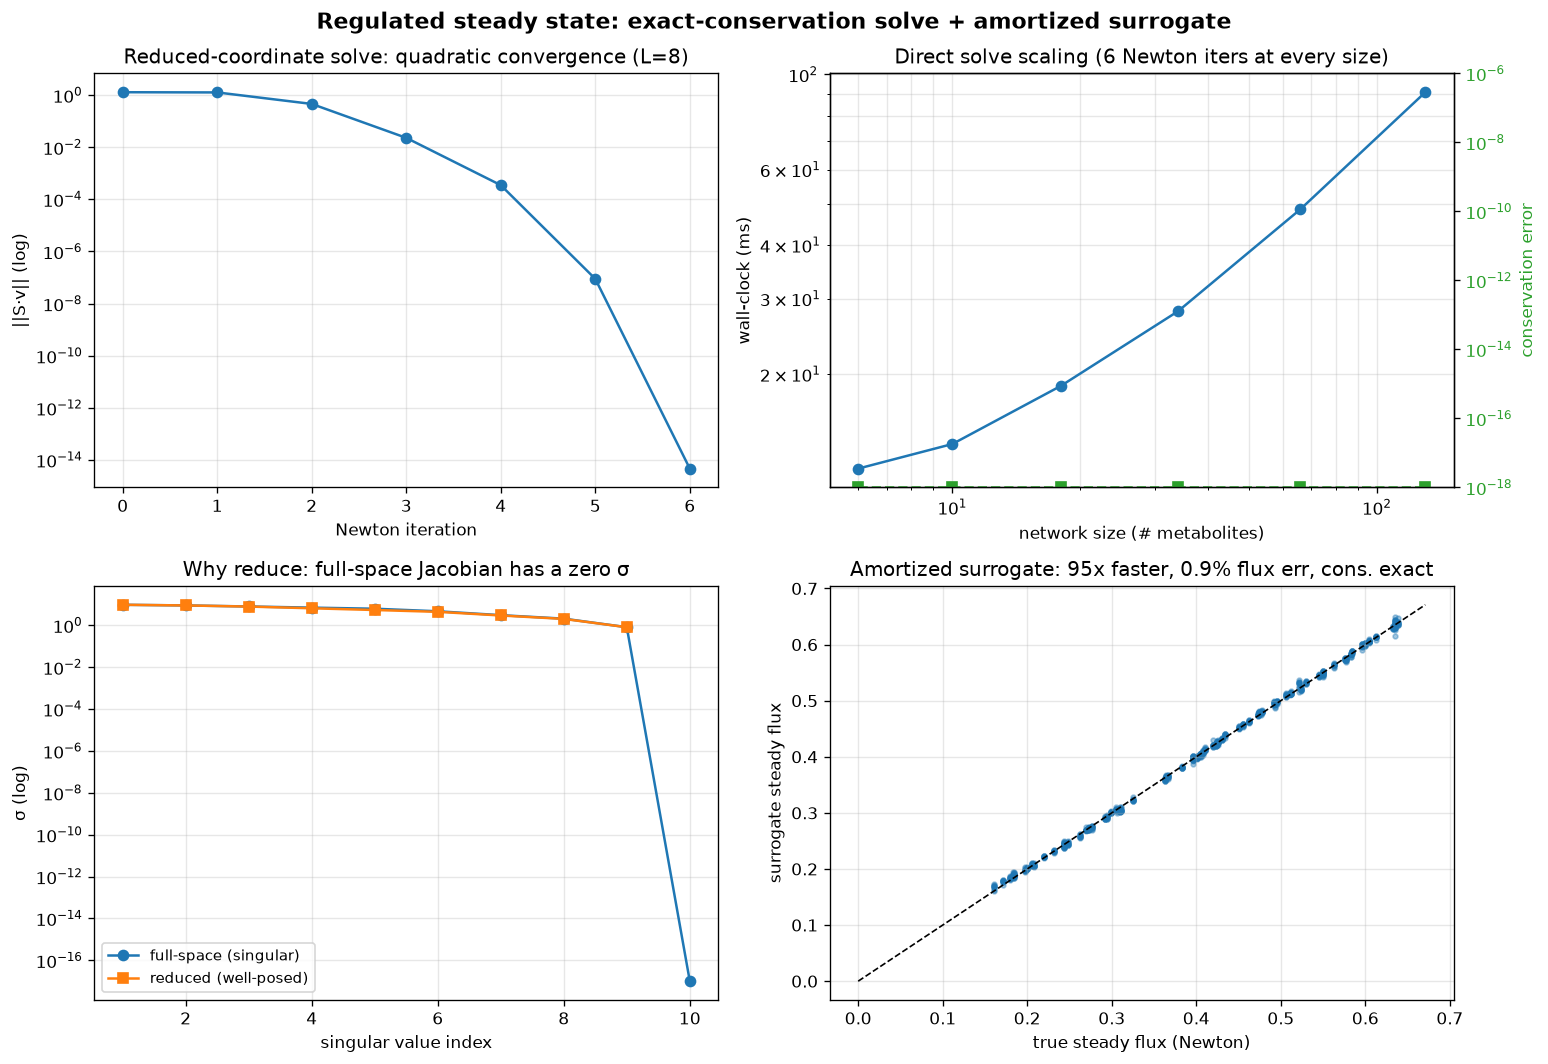

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (1) Newton convergence (quadratic)
ax[0,0].semilogy(range(len(hist)), hist, 'o-')
ax[0,0].set_xlabel('Newton iteration'); ax[0,0].set_ylabel('||S·v|| (log)')
ax[0,0].set_title('Reduced-coordinate solve: quadratic convergence (L=8)')
ax[0,0].grid(True, alpha=0.3)

# (2) scaling
ax[0,1].loglog(sizes, times, 'o-', label='solve time')
ax[0,1].set_xlabel('network size (# metabolites)'); ax[0,1].set_ylabel('wall-clock (ms)')
ax[0,1].set_title(f'Direct solve scaling ({iters_list[0]} Newton iters at every size)')
ax[0,1].grid(True, which='both', alpha=0.3)
axt = ax[0,1].twinx()
axt.semilogy(sizes, [max(c,1e-18) for c in cons_list], 's--', color='tab:green', label='conservation err')
axt.set_ylabel('conservation error', color='tab:green'); axt.set_ylim(1e-18, 1e-6)
axt.tick_params(axis='y', labelcolor='tab:green')

# (3) Jacobian spectra: full (singular) vs reduced
ax[1,0].semilogy(range(1, len(sv_full)+1), sv_full.numpy(), 'o-', label='full-space (singular)')
ax[1,0].semilogy(range(1, len(sv_red)+1), sv_red.numpy(), 's-', label='reduced (well-posed)')
ax[1,0].set_xlabel('singular value index'); ax[1,0].set_ylabel('σ (log)')
ax[1,0].set_title('Why reduce: full-space Jacobian has a zero σ')
ax[1,0].legend(fontsize=9); ax[1,0].grid(True, alpha=0.3)

# (4) surrogate parity on steady fluxes
ax[1,1].scatter(Vte.flatten().numpy(), Vp.flatten().numpy(), s=8, alpha=0.4)
lim = [0, float(Vte.max())*1.05]
ax[1,1].plot(lim, lim, 'k--', lw=1)
ax[1,1].set_xlabel('true steady flux (Newton)'); ax[1,1].set_ylabel('surrogate steady flux')
ax[1,1].set_title(f'Amortized surrogate: {newton_t/sur_t:.0f}x faster, '
                  f'{flux_err*100:.1f}% flux err, cons. exact')
ax[1,1].grid(True, alpha=0.3)

plt.suptitle('Regulated steady state: exact-conservation solve + amortized surrogate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('regulated_steady_state_results.png', dpi=120, bbox_inches='tight')
plt.show()

## Takeaways, and how this answers the scaling question

**What actually helped — and it wasn't learning the kinetics.**

- **Conservation is free leverage, and it is linear algebra.** The conserved moiety is the
  left null space of `S`. Using it to solve in reduced coordinates turned a *singular*
  nonlinear system into a well-posed one (compare the two Jacobian spectra), removed a
  degree of freedom, and held mass balance at machine precision for every network size.
  This is exactly the part Cajal is built to represent exactly — `S` and its null space
  are typed linear maps; the nonlinear root-find and the surrogate live around that scaffold.
- **Amortization is the real scaling move.** Pay once to solve a few hundred regulated
  steady states; then answer new conditions ~100x faster with a surrogate that, because it
  predicts in reduced coordinates, **cannot** violate conservation. That is the regulated
  analogue of what FBA gives cheaply — but with the regulation kept, not discarded.

**Where this sits, honestly.**

- This is **not** PINNs, and deliberately so: PINNs enforce physics softly in a loss and
  struggle on stiff kinetics; here conservation is enforced *exactly, by construction*, and
  the expensive solve is amortized rather than learned-as-a-residual.
- **Caveats.** The network and kinetics are synthetic and non-stiff, chosen so the scaling
  and conservation story is legible; real reconstructions are stiffer and have richer null
  spaces (multiple moieties, e.g. the full ATP/ADP, NAD(P)/NAD(P)H, CoA pools). The
  reduction generalizes — `c` becomes a *basis* for the left null space of `S`, computed
  once — but stiffness will demand better globalization (line search / trust region /
  homotopy) than the plain damped Newton here. The surrogate was trained on solver output;
  the scientifically important version trains the same structured map against **measured
  fluxomics/metabolomics**, so you get a fast, conservation-guaranteed, *regulated*
  steady-state model without ever integrating the intractable full ODE. That is the
  frontier-middle target — and the open hard part is that real regulatory data is sparse.